# Comptage des occurrences des personnages par tome

Ce notebook :

1. lit le fichier `.ods` des personnages ;
2. construit, pour chaque personnage, une liste de variantes de noms à partir des **3 premières colonnes** :
   - `NOMS HUMAINS`
   - `SECOND NOM`
   - `TROISIEME NOM`
3. prend en compte les combinaisons demandées :
   - `1 + 2`
   - `2 + 3`
   - `1 + 2 + 3`
   - `1 + 3`
4. compte les occurrences de chaque personnage dans chaque **tome** (`book`) du fichier `.csv` ;
5. exporte un tableau final qui reprend la structure du tableau `.ods` et ajoute une colonne par tome.

## Remarque importante
Par défaut, le notebook compte aussi les **formes simples** (`1`, `2`, `3`) quand elles existent.  
C'est pratique pour éviter que les personnages à nom simple aient toujours `0`.

Si tu veux **strictement** ne compter que les combinaisons demandées, mets :

```python
INCLUDE_SINGLE_NAMES = False
```
dans la cellule de paramètres.


In [10]:
# Paramètres
ODS_PATH = "../Noms personnages.ods"
CSV_PATH = "../Texte/La-ballade-de-Pern-intégrale-sentences-lemma.csv"
ODS_SHEET = "Noms et genres persos"

# True = compte aussi les noms simples (recommandé)
# False = ne compte QUE 1+2, 2+3, 1+2+3, 1+3
INCLUDE_SINGLE_NAMES = True

# Colonne texte à analyser dans le CSV
TEXT_COLUMN = "text"

# Fichiers de sortie
OUTPUT_XLSX = "pern_occurrences_par_tome.xlsx"
OUTPUT_CSV = "pern_occurrences_par_tome.csv"
OUTPUT_ALIASES_CSV = "pern_aliases_utilises.csv"


In [11]:
import pandas as pd
import re
from pathlib import Path
from collections import defaultdict

In [12]:
# Lecture des fichiers
names_df = pd.read_excel(ODS_PATH, sheet_name=ODS_SHEET, engine="odf")
text_df = pd.read_csv(CSV_PATH)

print("Dimensions ODS :", names_df.shape)
print("Dimensions CSV :", text_df.shape)
print("\nColonnes ODS :", list(names_df.columns))
print("\nColonnes CSV :", list(text_df.columns))

Dimensions ODS : (1026, 7)
Dimensions CSV : (132850, 7)

Colonnes ODS : ['Noms humains', 'Second nom', 'Troisième nom', 'Quatrième nom', 'H/F/Na', 'ID unique', 'Morts']

Colonnes CSV : ['sentence_id', 'book', 'parution', 'start_pdf_page', 'end_pdf_page', 'text', 'text_lemma']


In [14]:
# Vérifications minimales
required_name_cols = ["Noms humains", "Second nom", "Troisième nom", "Quatrième nom", "ID unique"]
required_csv_cols = ["book", TEXT_COLUMN]

missing_ods = [c for c in required_name_cols if c not in names_df.columns]
missing_csv = [c for c in required_csv_cols if c not in text_df.columns]

if missing_ods:
    raise ValueError(f"Colonnes manquantes dans le ODS : {missing_ods}")

if missing_csv:
    raise ValueError(f"Colonnes manquantes dans le CSV : {missing_csv}")

print("Vérification OK.")

Vérification OK.


In [15]:
def clean_part(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    return x if x else None


def build_aliases(row, include_single_names=True):
    """Construit les variantes d'un personnage à partir des 3 premières colonnes."""
    p1 = clean_part(row["Noms humains"])
    p2 = clean_part(row["Second nom"])
    p3 = clean_part(row["Troisième nom"])

    aliases = []

    # Optionnel : formes simples
    if include_single_names:
        for p in (p1, p2, p3):
            if p:
                aliases.append(p)

    # Combinaisons demandées
    if p1 and p2:
        aliases.append(f"{p1} {p2}")      # 1 + 2
    if p2 and p3:
        aliases.append(f"{p2} {p3}")      # 2 + 3
    if p1 and p2 and p3:
        aliases.append(f"{p1} {p2} {p3}") # 1 + 2 + 3
    if p1 and p3:
        aliases.append(f"{p1} {p3}")      # 1 + 3

    # Déduplication en conservant l'ordre
    seen = set()
    clean_aliases = []
    for a in aliases:
        a = re.sub(r"\s+", " ", a).strip()
        key = a.lower()
        if key not in seen:
            seen.add(key)
            clean_aliases.append(a)

    # Important : les alias longs d'abord pour éviter le double comptage
    clean_aliases = sorted(clean_aliases, key=lambda x: (-len(x), x.lower()))
    return clean_aliases


names_df["aliases"] = names_df.apply(
    lambda row: build_aliases(row, include_single_names=INCLUDE_SINGLE_NAMES),
    axis=1
)

names_df[["Noms humains", "Second nom", "Troisième nom", "Quatrième nom", "ID unique", "aliases"]].head(15)

,Noms humains,Second nom,Troisième nom,Quatrième nom,ID unique,aliases
0,Adessa,NaN,NaN,NaN,6,[Adessa]
1,Armald,NaN,NaN,NaN,33,[Armald]
2,B’ner,NaN,NaN,NaN,49,[B’ner]
3,Barly,NaN,NaN,NaN,67,[Barly]
4,Berchar,Berch,NaN,NaN,88,"[Berchar Berch, Berchar, Berch]"
5,Betrice,NaN,NaN,NaN,96,[Betrice]
6,Brare,NaN,NaN,NaN,119,[Brare]
7,C’gan,NaN,NaN,NaN,143,[C’gan]
8,Caesar,Galliani,NaN,NaN,151,"[Caesar Galliani, Galliani, Caesar]"
9,Carola,NaN,NaN,NaN,162,[Carola]


In [16]:
# Tableau d'audit des alias réellement utilisés
aliases_audit = names_df[["Noms humains", "Second nom", "Troisième nom", "Quatrième nom", "ID unique", "aliases"]].copy()
aliases_audit["aliases"] = aliases_audit["aliases"].apply(lambda x: " | ".join(x))
aliases_audit.to_csv(OUTPUT_ALIASES_CSV, index=False)
print(f"Fichier alias exporté : {OUTPUT_ALIASES_CSV}")
aliases_audit.head(10)

Fichier alias exporté : pern_aliases_utilises.csv


,Noms humains,Second nom,Troisième nom,Quatrième nom,ID unique,aliases
0,Adessa,NaN,NaN,NaN,6,Adessa
1,Armald,NaN,NaN,NaN,33,Armald
2,B’ner,NaN,NaN,NaN,49,B’ner
3,Barly,NaN,NaN,NaN,67,Barly
4,Berchar,Berch,NaN,NaN,88,Berchar Berch | Berchar | Berch
5,Betrice,NaN,NaN,NaN,96,Betrice
6,Brare,NaN,NaN,NaN,119,Brare
7,C’gan,NaN,NaN,NaN,143,C’gan
8,Caesar,Galliani,NaN,NaN,151,Caesar Galliani | Galliani | Caesar
9,Carola,NaN,NaN,NaN,162,Carola


In [17]:
# Préparation des textes par tome
text_df = text_df.copy()
text_df = text_df[text_df["book"].notna()].copy()
text_df["book"] = text_df["book"].astype(int)

books = sorted(text_df["book"].unique())
print("Tomes détectés :", books)

book_texts = (
    text_df.groupby("book")[TEXT_COLUMN]
    .apply(lambda s: "\n".join(s.fillna("").astype(str)))
    .to_dict()
)

for b in books[:5]:
    print(f"Tome {b}: {len(book_texts[b]):,} caractères")

Tomes détectés : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
Tome 1: 777,188 caractères
Tome 2: 562,067 caractères
Tome 3: 634,318 caractères
Tome 4: 727,919 caractères
Tome 5: 240,296 caractères


In [18]:
def compile_character_pattern(aliases):
    """Crée une regex qui repère les alias du personnage avec bornes de mots."""
    if not aliases:
        return None

    escaped = [re.escape(a) for a in aliases]
    pattern = r"(?<!\w)(?:" + "|".join(escaped) + r")(?!\w)"
    return re.compile(pattern, flags=re.IGNORECASE)


def count_occurrences_in_text(pattern, text):
    if pattern is None:
        return 0
    return len(pattern.findall(text))

In [19]:
# Comptage des occurrences par personnage et par tome
count_data = defaultdict(list)

for i, row in names_df.iterrows():
    aliases = row["aliases"]
    pattern = compile_character_pattern(aliases)

    for book in books:
        n = count_occurrences_in_text(pattern, book_texts[book])
        count_data[f"book_{book}"].append(n)

    if (i + 1) % 100 == 0:
        print(f"{i + 1} personnages traités / {len(names_df)}")

print("Comptage terminé.")

100 personnages traités / 1026
200 personnages traités / 1026
300 personnages traités / 1026
400 personnages traités / 1026
500 personnages traités / 1026
600 personnages traités / 1026
700 personnages traités / 1026
800 personnages traités / 1026
900 personnages traités / 1026
1000 personnages traités / 1026
Comptage terminé.


In [20]:
# Assemblage du tableau final
output_df = names_df.drop(columns=["aliases"]).copy()

for col_name, values in count_data.items():
    output_df[col_name] = values

# Optionnel : total tous tomes confondus
book_cols = [f"book_{b}" for b in books]
output_df["total_occurrences"] = output_df[book_cols].sum(axis=1)

print(output_df.shape)
output_df.head(10)

(1026, 23)


,Noms humains,Second nom,Troisième nom,Quatrième nom,H/F/Na,ID unique,Morts,book_1,book_2,book_3,...,book_7,book_8,book_9,book_10,book_11,book_12,book_13,book_14,book_15,total_occurrences
0,Adessa,NaN,NaN,NaN,FEMME,6,True,0,0,0,...,4,0,0,0,0,0,0,0,0,4
1,Armald,NaN,NaN,NaN,HOMME,33,True,0,0,0,...,0,0,0,0,0,0,0,0,0,25
2,B’ner,NaN,NaN,NaN,HOMME,49,True,0,0,10,...,0,0,0,0,0,0,0,0,0,10
3,Barly,NaN,NaN,NaN,HOMME,67,True,0,0,0,...,0,0,0,0,0,0,0,0,0,3
4,Berchar,Berch,NaN,NaN,HOMME,88,True,0,0,0,...,0,0,0,0,0,0,0,0,0,41
5,Betrice,NaN,NaN,NaN,FEMME,96,True,0,0,0,...,73,0,0,0,0,0,0,0,0,73
6,Brare,NaN,NaN,NaN,HOMME,119,True,0,0,0,...,0,0,0,0,0,0,0,0,0,24
7,C’gan,NaN,NaN,NaN,HOMME,143,True,0,0,0,...,50,17,2,0,0,0,0,0,0,69
8,Caesar,Galliani,NaN,NaN,HOMME,151,True,14,0,0,...,0,0,0,0,0,0,0,0,0,14
9,Carola,NaN,NaN,NaN,FEMME,162,True,0,0,0,...,19,0,0,0,0,0,0,0,0,19


In [15]:
# Export
#output_df.to_excel(OUTPUT_XLSX, index=False)
output_df.to_csv(OUTPUT_CSV, index=False)

#print(f"Fichier Excel exporté : {OUTPUT_XLSX}")
print(f"Fichier CSV exporté   : {OUTPUT_CSV}")

Fichier CSV exporté   : pern_occurrences_par_tome.csv


## Protagonist Index: definition and interpretation

The **Protagonist Index (PI)** quantifies how central a character is within a given book while also capturing how strongly that character is associated with that specific book across the entire series.

It combines two complementary components:

---

### 1. Relative frequency within a book

This measures how prominent a character is *within a given book*:

$$
\text{Relative Frequency}_{i,j} = \frac{\text{occurrences of character } i \text{ in book } j}{\text{total occurrences of all characters in book } j}
$$

- High value → the character is frequently mentioned in that book  
- Captures **local importance**

---

### 2. Specificity across books

This measures how much a character is associated with a particular book compared to others:

$$
\text{Specificity}_{i,j} = \frac{\text{occurrences of character } i \text{ in book } j}{\text{total occurrences of character } i \text{ across all books}}
$$

- High value → the character mainly appears in that book  
- Captures **narrative localization**

---

### 3. Protagonist Index

The Protagonist Index is defined as:

$$
\text{PI}_{i,j} = \text{Relative Frequency}_{i,j} \times \text{Specificity}_{i,j}
$$

---

### Interpretation

- **High PI**  
  → character is both:
  - very frequent in the book  
  - strongly associated with that book  
  ⇒ likely a **main protagonist of that specific book**

- **High frequency, low specificity**  
  → character appears often across many books  
  ⇒ **recurring major character**

- **Low frequency, high specificity**  
  → character appears mostly in one book but not often  
  ⇒ **local minor character**

- **Low PI**  
  → background character


### Intuition

The Protagonist Index identifies characters who are not just frequent, but **distinctively central to a particular book**, making it especially useful for tracking narrative focus across a series.

In [23]:
# read the output from the previous code
output_df = pd.read_csv("pern_occurrences_par_tome.csv")

In [24]:
# =========================
# LIBRARIES
# =========================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

sns.set_theme(style="white")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300

In [28]:
# =========================
# DATA PREPARATION
# =========================

# make a copy from the table
df = output_df.copy()

# REMOVE DUPLICATES (keep first occurrence of each character)
df = df.drop_duplicates(subset="ID unique", keep="first")

# make full names + unique ID
name_cols = ["Noms humains", "Second nom", "Troisième nom", "Quatrième nom","ID unique"]
# keep only existing columns
name_cols = [col for col in name_cols if col in df.columns]

df["full_name"] = (
    df[name_cols]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# fallback to id if name missing
df["full_name"] = df["full_name"].replace("", np.nan)
df["full_name"] = df["full_name"].fillna(df["ID unique"].astype(str))

# use full names as index
df = df.set_index("full_name")

# keep only book columns
book_cols = [col for col in df.columns if col.startswith("book_")]
df = df[book_cols]

# make sure all the data is numeric format
df = df.apply(pd.to_numeric, errors="coerce").fillna(0)

# remove characters with zero occurrences
df = df.loc[df.sum(axis=1) > 0]

# see how many rows and columns
print(df.shape)
# see the top rows
df.head()

(1026, 15)


,book_1,book_2,book_3,book_4,book_5,book_6,book_7,book_8,book_9,book_10,book_11,book_12,book_13,book_14,book_15
full_name,,,,,,,,,,,,,,,
Adessa 6,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0
Armald 33,0,0,0,0,0,25,0,0,0,0,0,0,0,0,0
B’ner 49,0,0,10,0,0,0,0,0,0,0,0,0,0,0,0
Barly 67,0,0,0,2,0,1,0,0,0,0,0,0,0,0,0
Berchar Berch 88,0,0,0,40,0,1,0,0,0,0,0,0,0,0,0


In [29]:
# =========================
# RELATIVE FREQUENCY
# =========================

df_rel = df.div(df.sum(axis=0), axis=1)

df_rel.head()

,book_1,book_2,book_3,book_4,book_5,book_6,book_7,book_8,book_9,book_10,book_11,book_12,book_13,book_14,book_15
full_name,,,,,,,,,,,,,,,
Adessa 6,0.0,0.0,0.000000,0.000000,0.0,0.00000,0.000628,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Armald 33,0.0,0.0,0.000000,0.000000,0.0,0.00425,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B’ner 49,0.0,0.0,0.002447,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Barly 67,0.0,0.0,0.000000,0.000374,0.0,0.00017,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Berchar Berch 88,0.0,0.0,0.000000,0.007474,0.0,0.00017,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
# =========================
# SPECIFICITY
# =========================

df_specificity = df.div(df.sum(axis=1), axis=0)
df_specificity = df_specificity.fillna(0)

df_specificity.head()

,book_1,book_2,book_3,book_4,book_5,book_6,book_7,book_8,book_9,book_10,book_11,book_12,book_13,book_14,book_15
full_name,,,,,,,,,,,,,,,
Adessa 6,0.0,0.0,0.0,0.000000,0.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Armald 33,0.0,0.0,0.0,0.000000,0.0,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B’ner 49,0.0,0.0,1.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Barly 67,0.0,0.0,0.0,0.666667,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Berchar Berch 88,0.0,0.0,0.0,0.975610,0.0,0.024390,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
# =========================
# PROTAGONIST INDEX
# =========================

protagonist_index = df_rel * df_specificity

protagonist_index.head()

,book_1,book_2,book_3,book_4,book_5,book_6,book_7,book_8,book_9,book_10,book_11,book_12,book_13,book_14,book_15
full_name,,,,,,,,,,,,,,,
Adessa 6,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000628,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Armald 33,0.0,0.0,0.000000,0.000000,0.0,0.004250,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B’ner 49,0.0,0.0,0.002447,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Barly 67,0.0,0.0,0.000000,0.000249,0.0,0.000057,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Berchar Berch 88,0.0,0.0,0.000000,0.007292,0.0,0.000004,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
# =========================
# TOP PROTAGONISTS
# =========================
# extract top n protagnists per book
TOP_N = 10

top_protagonists = {
    col: protagonist_index[col].sort_values(ascending=False).head(TOP_N)
    for col in protagonist_index.columns
}
# print them
for book, series in top_protagonists.items():
    print(f"\n===== {book} =====")
    print(series)


===== book_1 =====
full_name
Sean Connell O’Connell 821    0.077232
Sorka 868                     0.062091
Paul Logorides 717            0.058497
Sallah Telgar-Andiyar 808     0.039278
Sallah 807                    0.039278
Pol Nietro 741                0.030789
Sabra Ongola Stein 802        0.030683
Bay Harkenon 75               0.029674
Zi Ongola 1026                0.028954
Pol 740                       0.028930
Name: book_1, dtype: float64

===== book_2 =====
full_name
T’lion Gaddie 896        0.119960
Readis 769               0.101761
Alemi Onclemi Lemi 14    0.095112
Alemi 15                 0.087639
Persellan 726            0.024394
Boskoney 113             0.010767
Kami 481                 0.008141
Idarolan Iddie 415       0.007710
Jayge Lilcamp 439        0.007469
Kitrin 504               0.006828
Name: book_2, dtype: float64

===== book_3 =====
full_name
Iantine Ian 414      0.092244
Chalkin 171          0.074138
K’vin Kev 475        0.072914
Paulin 719           0.061659
Zu

In [33]:
# =========================
# SELECT TOP CHARACTERS
# =========================

# select the number of total characters you want
N_CHARACTERS = 40
# for each row/character, take the maximum value
# get how important was a character at its peak
# sort and then take the top(head) 40 characters in the list
top_chars = protagonist_index.max(axis=1).sort_values(ascending=False).head(N_CHARACTERS).index

# filter the dataset to keep only the selected characters
plot_data = protagonist_index.loc[top_chars]

# finding where each character peaks
# find the book and the value
peak_book = plot_data.idxmax(axis=1)
peak_value = plot_data.max(axis=1)

# put them in a data frame in order
ordering_df = pd.DataFrame({
    "peak_book": peak_book,
    "peak_value": peak_value
}, index=plot_data.index)

# convert book names into numeric order
ordering_df["book_order"] = ordering_df["peak_book"].map(
    {book: i for i, book in enumerate(plot_data.columns)}
)

# sort characters by order of book and their value
ordering_df = ordering_df.sort_values(
    by=["book_order", "peak_value"],
    ascending=[True, False]
)

# apply the ordering
plot_data = plot_data.loc[ordering_df.index]
# visualize
plot_data.head()

,book_1,book_2,book_3,book_4,book_5,book_6,book_7,book_8,book_9,book_10,book_11,book_12,book_13,book_14,book_15
full_name,,,,,,,,,,,,,,,
Sean Connell O’Connell 821,0.077232,0.00000,0.000016,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,2.392913e-06,0.000000e+00
Sorka 868,0.062091,0.00000,0.000002,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,1.342115e-06,0.000000e+00
Paul Logorides 717,0.058497,0.00000,0.000000,0.0,0.0,4.066538e-07,0.0,0.0,0.0,0.000001,6.966641e-07,8.890169e-07,0.0,3.523854e-07,4.476693e-07
Sallah Telgar-Andiyar 808,0.039278,0.00000,0.000000,0.0,0.0,5.362186e-07,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,2.248953e-04,0.000000e+00
T’lion Gaddie 896,0.000000,0.11996,0.000000,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,0.000000e+00,1.509079e-04


NameError: name 'nature_cmap' is not defined

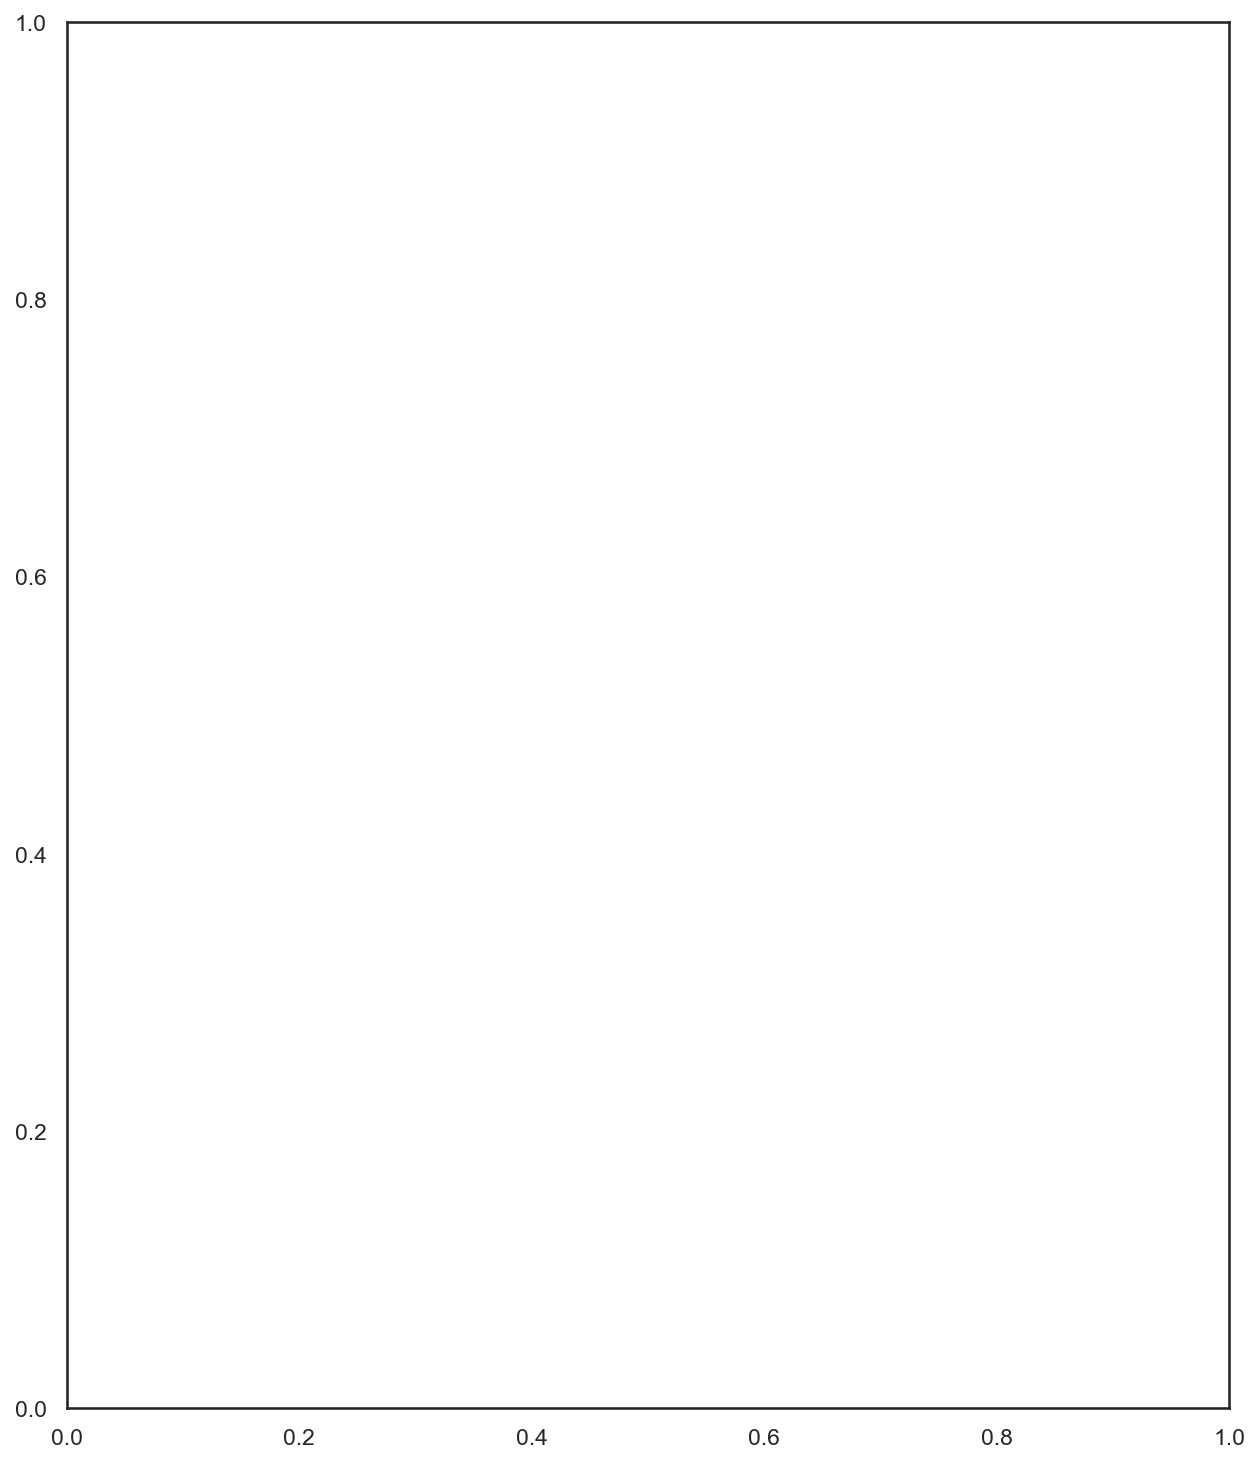

In [34]:
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(10, 12))

sns.heatmap(
    plot_data,
    cmap=nature_cmap,
    norm=LogNorm(vmin=plot_data.min().min() + 1e-6, vmax=plot_data.max().max()),
    linewidths=0.3,
    linecolor="0.9",
    cbar_kws={"label": "Protagonist Index (log scale)"},
    ax=ax
)

ax.set_title("Character prominence across books", pad=12, weight="bold")
ax.set_xlabel("Book")
ax.set_ylabel("Character (id unique)")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

In [35]:
# =========================
# EXPORT
# =========================

df_rel.to_csv("relative_frequency_books.csv")
df_specificity.to_csv("specificity_books.csv")
protagonist_index.to_csv("protagonist_index_books.csv")

---

### Type token ratio per gender

We count the diversity of people in the top characters

---

In [36]:
import pandas as pd

# -------------------------
# FILE PATHS
# -------------------------
protagonist_file = "protagonist_index_books.csv"
characters_file = "../Noms personnages.ods"

# -------------------------
# LOAD DATA
# -------------------------
protagonist_index = pd.read_csv(protagonist_file)

# If first column is character name
protagonist_index = protagonist_index.set_index(protagonist_index.columns[0])

# Read ODS (requires odfpy installed)
characters_df = pd.read_excel(
    characters_file,
    engine="odf"
)

print(protagonist_index.head())
print(characters_df.head())

                  book_1  book_2    book_3    book_4  book_5    book_6  \
full_name                                                                
Adessa 6             0.0     0.0  0.000000  0.000000     0.0  0.000000   
Armald 33            0.0     0.0  0.000000  0.000000     0.0  0.004250   
B’ner 49             0.0     0.0  0.002447  0.000000     0.0  0.000000   
Barly 67             0.0     0.0  0.000000  0.000249     0.0  0.000057   
Berchar Berch 88     0.0     0.0  0.000000  0.007292     0.0  0.000004   

                    book_7  book_8  book_9  book_10  book_11  book_12  \
full_name                                                               
Adessa 6          0.000628     0.0     0.0      0.0      0.0      0.0   
Armald 33         0.000000     0.0     0.0      0.0      0.0      0.0   
B’ner 49          0.000000     0.0     0.0      0.0      0.0      0.0   
Barly 67          0.000000     0.0     0.0      0.0      0.0      0.0   
Berchar Berch 88  0.000000     0.0     0.0 

In [37]:
import pandas as pd
import re

# Example: adapt column names if needed
ID_COL = "ID unique"
GENDER_COL = "H/F/Na"   # or "Genre", "gender", etc.

# -------------------------
# CLEAN ODS GENDER TABLE
# -------------------------
gender_df = characters_df[[ID_COL, GENDER_COL]].dropna(subset=[ID_COL])

# Keep only first occurrence of each unique ID
gender_df = gender_df.drop_duplicates(subset=ID_COL, keep="first").copy()

# Make sure ID is numeric when possible
gender_df[ID_COL] = pd.to_numeric(gender_df[ID_COL], errors="coerce")

# Remove rows where ID could not be converted
gender_df = gender_df.dropna(subset=[ID_COL])

# Convert to integer if IDs are integers
gender_df[ID_COL] = gender_df[ID_COL].astype(int)

# -------------------------
# CREATE ID -> GENDER MAP
# -------------------------
gender_map = dict(zip(gender_df[ID_COL], gender_df[GENDER_COL]))

# -------------------------
# FUNCTION TO EXTRACT NUMERIC ID
# FROM FULL NAME STRING
# -------------------------
def extract_numeric_id(name):
    """
    Extract the first numeric sequence from a character name.
    Example:
        'Menolly_123' -> 123
        'Lessa 45'    -> 45
    Returns None if no numeric sequence is found.
    """
    if pd.isna(name):
        return None
    
    match = re.search(r'(\d+)', str(name))
    if match:
        return int(match.group(1))
    return None

# -------------------------
# APPLY TO PROTAGONIST INDEX
# -------------------------
# If protagonist_index index contains the full names
protagonist_index = protagonist_index.copy()

protagonist_index["numeric_id"] = protagonist_index.index.to_series().apply(extract_numeric_id)
protagonist_index["gender"] = protagonist_index["numeric_id"].map(gender_map)


In [38]:
TOP_N = 10

books = [col for col in protagonist_index.columns if col.startswith("book_")]

top_by_book = {}

for book in books:
    top_chars = (
        protagonist_index[book]
        .sort_values(ascending=False)
        .head(TOP_N)
    )
    
    df_top = protagonist_index.loc[top_chars.index]
    
    top_by_book[book] = df_top

# Example
top_by_book["book_1"].head()

,book_1,book_2,book_3,book_4,book_5,book_6,book_7,book_8,book_9,book_10,book_11,book_12,book_13,book_14,book_15,numeric_id,gender
full_name,,,,,,,,,,,,,,,,,
Sean Connell O’Connell 821,0.077232,0.0,0.000016,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,2.392913e-06,0.000000e+00,821,HOMME
Sorka 868,0.062091,0.0,0.000002,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,1.342115e-06,0.000000e+00,868,FEMME
Paul Logorides 717,0.058497,0.0,0.000000,0.0,0.0,4.066538e-07,0.0,0.0,0.0,0.000001,6.966641e-07,8.890169e-07,0.0,3.523854e-07,4.476693e-07,717,HOMME
Sallah Telgar-Andiyar 808,0.039278,0.0,0.000000,0.0,0.0,5.362186e-07,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,2.248953e-04,0.000000e+00,808,FEMME
Sallah 807,0.039278,0.0,0.000000,0.0,0.0,5.362186e-07,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,2.248953e-04,0.000000e+00,807,FEMME


In [39]:
import pandas as pd
import numpy as np

# -------------------------
# COLLECT ALL TOP-10 TOKENS ACROSS BOOKS
# -------------------------
all_top_tokens = []

for book, df_top in top_by_book.items():
    df = df_top.dropna(subset=["gender"]).copy()
    
    # keep full name as a column
    df = df.reset_index().rename(columns={df.index.name if df.index.name else "index": "full_name"})
    
    # if the reset_index name handling above behaves oddly, use this instead:
    # df = df.reset_index()
    # df = df.rename(columns={df.columns[0]: "full_name"})
    
    df["book"] = book
    
    all_top_tokens.append(df[["book", "full_name", "gender"]])

all_top_tokens_df = pd.concat(all_top_tokens, ignore_index=True)

all_top_tokens_df.head()

,book,full_name,gender
0,book_1,Sean Connell O’Connell 821,HOMME
1,book_1,Sorka 868,FEMME
2,book_1,Paul Logorides 717,HOMME
3,book_1,Sallah Telgar-Andiyar 808,FEMME
4,book_1,Sallah 807,FEMME


In [40]:
# compute TTR
results = []

for gender_cat, sub_df in all_top_tokens_df.groupby("gender"):
    
    # TOKENS = all appearances in top-10 lists across books
    tokens = len(sub_df)
    
    # TYPES = distinct character full names
    types = sub_df["full_name"].nunique()
    
    # TTR
    ttr = types / tokens if tokens > 0 else np.nan
    
    results.append({
        "gender": gender_cat,
        "tokens": tokens,
        "types": types,
        "TTR": ttr
    })

ttr_global_gender_df = pd.DataFrame(results).sort_values("gender")

ttr_global_gender_df

,gender,tokens,types,TTR
0,FEMME,52,42,0.807692
1,HOMME,98,85,0.867347
